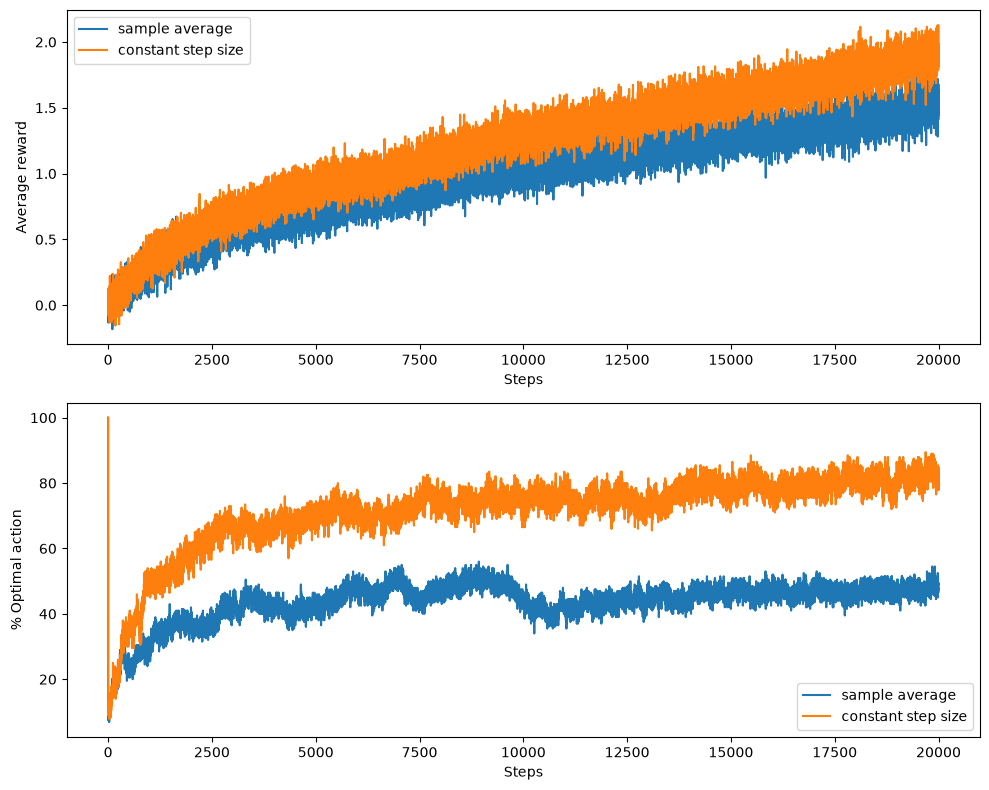

In [ ]:
# Exercise 2.5: non-stationary 10-armed bandit
# Comparing sample average vs constant step size (alpha=0.1) on a non-stationary bandit where true rewards drift due to random walk (mean=0, std=0.01 per step).
# epsilon=0.1, 20000 steps, 200 runs.
# Result: Constant step size tracks changes better.
import numpy as np
import matplotlib.pyplot as plt
import random

def bandit(action, true_rewards):
    reward = random.gauss(true_rewards[action],1)
    return reward

def sample_average(true_rewards,value_estimates,action_chosen,epsilon,steps,rewards,optimal_choice):
    for step in range(1, steps + 1):
        if random.random() < epsilon:
            index = random.randint(0,9)
            action = index
        else:
            greediest_value = max(value_estimates)
            greedy_actions = []
            for action, value in enumerate(value_estimates):
                if value == greediest_value:
                    greedy_actions.append(action)
            action = random.choice(greedy_actions)
        reward = bandit(action,true_rewards)
        action_chosen[action] += 1
        value_estimates[action] = value_estimates[action] + (1/action_chosen[action]) * (reward - value_estimates[action])
        rewards.append(reward)
        if true_rewards[action] == max(true_rewards):
            optimal_choice.append(100)
        else:
            optimal_choice.append(0)

def step_size(true_rewards,value_estimates,action_chosen,epsilon,step_size,steps,rewards,optimal_choice):
    for step in range(1, steps + 1):
        if random.random() < epsilon:
            index = random.randint(0,9)
            action = index
        else:
            greediest_value = max(value_estimates)
            greedy_actions = []
            for action, value in enumerate(value_estimates):
                if value == greediest_value:
                    greedy_actions.append(action)
            action = random.choice(greedy_actions)
        reward = bandit(action,true_rewards)
        action_chosen[action] += 1
        value_estimates[action] = value_estimates[action] + step_size * (reward - value_estimates[action])
        rewards.append(reward)
        if true_rewards[action] == max(true_rewards):
            optimal_choice.append(100)
        else:
            optimal_choice.append(0)

def main():
    

    steps = 20000
    runs = 10
    avg_rewards = np.zeros(steps)
    optimal_pct = np.zeros(steps)
    avg_rewards_alt = np.zeros(steps)
    optimal_pct_alt = np.zeros(steps)
    
    for run in range(1, runs + 1):
        true_rewards  = [0,0,0,0,0,0,0,0,0,0]
        value_estimates = [0,0,0,0,0,0,0,0,0,0]
        action_chosen = [0,0,0,0,0,0,0,0,0,0]
        alt_value_estimates = [0,0,0,0,0,0,0,0,0,0]
        alt_action_chosen = [0,0,0,0,0,0,0,0,0,0]
        rewards = []
        optimal_choice = []
        alt_rewards = []
        alt_optimal_choice = []
        for step in range(1,steps + 1):
            sample_average(true_rewards,value_estimates,action_chosen,0.1,1,rewards,optimal_choice)
            step_size(true_rewards,alt_value_estimates,alt_action_chosen,0.1,0.1,1, alt_rewards,alt_optimal_choice)
            for reward in range(10):
                true_rewards[reward] += random.gauss(0,.01)
        avg_rewards += rewards
        optimal_pct += optimal_choice
        avg_rewards_alt += alt_rewards
        optimal_pct_alt += alt_optimal_choice
    avg_rewards /= runs
    optimal_pct /= runs
    avg_rewards_alt /= runs
    optimal_pct_alt /= runs

    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(avg_rewards, label='sample average')
    ax1.plot(avg_rewards_alt, label='constant step size')
    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Average reward')
    ax1.legend()

    ax2.plot(optimal_pct, label='sample average')
    ax2.plot(optimal_pct_alt, label='constant step size')
    ax2.set_xlabel('Steps')
    ax2.set_ylabel('% Optimal action')
    ax2.legend()

    plt.tight_layout()
    plt.show()

main()